In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statistics import mean, stdev

In [2]:
sns.set_style('darkgrid')
cmap=sns.light_palette("seagreen",as_cmap=True)
pd.set_option('display.float_format','{:.4f}'.format)

In [3]:
unfair = pd.read_csv('../benchmark/heart-result/unfair_lr-100.csv', index_col=0)
zhang = pd.read_csv('../benchmark/heart-result/zhang-100.csv', index_col=0)

In [4]:
unfair = unfair.drop([0,1,2,3,4], axis=0)
unfair

,model_name,cv_seed,clas_acc,dp,deqodds,deqopp,trade_dp,trade_deqodds,trade_deqopp,TN_a0,FP_a0,FN_a0,TP_a0,TN_a1,FP_a1,FN_a1,TP_a1
5,UnfairLR,13,0.8477,0.7037,0.8327,0.7867,0.7690,0.8401,0.8160,20.0000,2.0000,0.0000,60.0000,78.0000,21.0000,16.0000,59.0000
6,UnfairLR,29,0.8867,0.6863,0.9265,0.8571,0.7737,0.9062,0.8717,18.0000,3.0000,0.0000,56.0000,87.0000,15.0000,11.0000,66.0000
7,UnfairLR,42,0.8359,0.6860,0.8857,0.8439,0.7536,0.8601,0.8399,18.0000,7.0000,1.0000,55.0000,84.0000,22.0000,12.0000,57.0000
8,UnfairLR,55,0.8398,0.7180,0.9152,0.8709,0.7741,0.8759,0.8551,16.0000,4.0000,1.0000,56.0000,79.0000,25.0000,11.0000,64.0000
9,UnfairLR,73,0.8711,0.6844,0.8936,0.8478,0.7666,0.8822,0.8593,21.0000,3.0000,1.0000,68.0000,79.0000,18.0000,11.0000,55.0000


In [5]:
zhang

,model_name,cv_seed,clas_acc,dp,deqodds,deqopp,trade_dp,trade_deqodds,trade_deqopp,TN_a0,FP_a0,FN_a0,TP_a0,TN_a1,FP_a1,FN_a1,TP_a1
0,Zhang4DP,13,0.8633,0.6871,0.8663,0.8033,0.7652,0.8648,0.8322,20.0000,2.0000,1.0000,59.0000,83.0000,16.0000,16.0000,59.0000
1,Zhang4DP,29,0.8828,0.6881,0.9282,0.8620,0.7734,0.9049,0.8723,18.0000,3.0000,1.0000,55.0000,88.0000,14.0000,12.0000,65.0000
2,Zhang4DP,42,0.8242,0.7116,0.9091,0.8507,0.7638,0.8646,0.8372,19.0000,6.0000,3.0000,53.0000,84.0000,22.0000,14.0000,55.0000
3,Zhang4DP,55,0.8555,0.7142,0.9047,0.8709,0.7785,0.8794,0.8631,17.0000,3.0000,1.0000,56.0000,82.0000,22.0000,11.0000,64.0000
4,Zhang4DP,73,0.8594,0.7074,0.9314,0.8920,0.7760,0.8939,0.8754,20.0000,4.0000,3.0000,66.0000,78.0000,19.0000,10.0000,56.0000
5,Zhang4EqOdds,13,0.8633,0.6871,0.8663,0.8033,0.7652,0.8648,0.8322,20.0000,2.0000,1.0000,59.0000,83.0000,16.0000,16.0000,59.0000
6,Zhang4EqOdds,29,0.8828,0.6881,0.9282,0.8620,0.7734,0.9049,0.8723,18.0000,3.0000,1.0000,55.0000,88.0000,14.0000,12.0000,65.0000
7,Zhang4EqOdds,42,0.8242,0.7116,0.9091,0.8507,0.7638,0.8646,0.8372,19.0000,6.0000,3.0000,53.0000,84.0000,22.0000,14.0000,55.0000
8,Zhang4EqOdds,55,0.8516,0.7198,0.8999,0.8709,0.7802,0.8750,0.8611,17.0000,3.0000,1.0000,56.0000,81.0000,23.0000,11.0000,64.0000
9,Zhang4EqOdds,73,0.8594,0.7074,0.9314,0.8920,0.7760,0.8939,0.8754,20.0000,4.0000,3.0000,66.0000,78.0000,19.0000,10.0000,56.0000


## Acc mean and std

In [6]:
unfair_acc = unfair.groupby(['model_name'])['clas_acc'].agg([mean, stdev])
zhang_acc = zhang.groupby(['model_name'])['clas_acc'].agg([mean, stdev])

In [7]:
acc = pd.concat([unfair_acc, zhang_acc])
acc = acc.reset_index()
acc = acc.rename(columns={'index': 'model_name'})
acc

,model_name,mean,stdev
0,UnfairLR,0.8562,0.0218
1,Zhang4DP,0.8570,0.0211
2,Zhang4EqOdds,0.8562,0.0213
3,Zhang4EqOpp,0.8602,0.0267


In [8]:
names = acc['model_name'].to_list()
for i in range(len(names)):
    if isinstance(names[i], tuple):
        names[i] = '-'.join([str(value) for value in names[i]])

names

['UnfairLR', 'Zhang4DP', 'Zhang4EqOdds', 'Zhang4EqOpp']

In [9]:
acc['model_name'] = names
acc

,model_name,mean,stdev
0,UnfairLR,0.8562,0.0218
1,Zhang4DP,0.8570,0.0211
2,Zhang4EqOdds,0.8562,0.0213
3,Zhang4EqOpp,0.8602,0.0267


In [10]:
print((acc['mean'].round(4).astype(str) + ' $\pm$ ' + acc['stdev'].round(4).astype(str)).to_string(index=False))

0.8562 $\pm$ 0.0218
 0.857 $\pm$ 0.0211
0.8562 $\pm$ 0.0213
0.8602 $\pm$ 0.0267


## Fairness mean and std

In [11]:
unfair_dp = unfair.groupby(['model_name'])['dp'].agg([mean, stdev])
zhang_dp = zhang.groupby(['model_name'])['dp'].agg([mean, stdev])

In [12]:
dp = pd.concat([unfair_dp, zhang_dp])
dp = dp.reset_index()
dp = dp.rename(columns={'index': 'model_name'})
dp['model_name'] = names
dp

,model_name,mean,stdev
0,UnfairLR,0.6957,0.0148
1,Zhang4DP,0.7017,0.0131
2,Zhang4EqOdds,0.7028,0.0146
3,Zhang4EqOpp,0.7053,0.0159


In [13]:
print((dp['mean'].round(4).astype(str) + ' $\pm$ ' + dp['stdev'].round(4).astype(str)).to_string(index=False))

0.6957 $\pm$ 0.0148
0.7017 $\pm$ 0.0131
0.7028 $\pm$ 0.0146
0.7053 $\pm$ 0.0159


In [14]:
unfair_deqodds = unfair.groupby(['model_name'])['deqodds'].agg([mean, stdev])
zhang_deqodds = zhang.groupby(['model_name'])['deqodds'].agg([mean, stdev])

In [15]:
deqodds = pd.concat([unfair_deqodds, zhang_deqodds])
deqodds = deqodds.reset_index()
deqodds = deqodds.rename(columns={'index': 'model_name'})
deqodds['model_name'] = names
deqodds

,model_name,mean,stdev
0,UnfairLR,0.8908,0.0363
1,Zhang4DP,0.9079,0.0260
2,Zhang4EqOdds,0.9070,0.0262
3,Zhang4EqOpp,0.9123,0.0391


In [16]:
print((deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.8908 $\pm$ 0.0363
 0.9079 $\pm$ 0.026
 0.907 $\pm$ 0.0262
0.9123 $\pm$ 0.0391


In [17]:
unfair_deqopp = unfair.groupby(['model_name'])['deqopp'].agg([mean, stdev])
zhang_deqopp = zhang.groupby(['model_name'])['deqopp'].agg([mean, stdev])

In [18]:
deqopp = pd.concat([unfair_deqopp, zhang_deqopp])
deqopp = deqopp.reset_index()
deqopp = deqopp.rename(columns={'index': 'model_name'})
deqopp['model_name'] = names
deqopp

,model_name,mean,stdev
0,UnfairLR,0.8413,0.0322
1,Zhang4DP,0.8558,0.0330
2,Zhang4EqOdds,0.8558,0.0330
3,Zhang4EqOpp,0.8701,0.0490


In [19]:
print((deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.8413 $\pm$ 0.0322
 0.8558 $\pm$ 0.033
 0.8558 $\pm$ 0.033
 0.8701 $\pm$ 0.049


## Trade-offs mean and std

In [20]:
unfair_trade_dp = unfair.groupby(['model_name'])['trade_dp'].agg([mean, stdev])
zhang_trade_dp = zhang.groupby(['model_name'])['trade_dp'].agg([mean, stdev])

In [21]:
trade_dp = pd.concat([unfair_trade_dp, zhang_trade_dp])
trade_dp = trade_dp.reset_index()
trade_dp = trade_dp.rename(columns={'index': 'model_name'})
trade_dp['model_name'] = names
trade_dp

,model_name,mean,stdev
0,UnfairLR,0.7674,0.0084
1,Zhang4DP,0.7714,0.0066
2,Zhang4EqOdds,0.7717,0.0070
3,Zhang4EqOpp,0.7750,0.0179


In [22]:
print((trade_dp['mean'].round(4).astype(str) + ' $\pm$ ' + trade_dp['stdev'].round(4).astype(str)).to_string(index=False))

0.7674 $\pm$ 0.0084
0.7714 $\pm$ 0.0066
 0.7717 $\pm$ 0.007
 0.775 $\pm$ 0.0179


In [23]:
unfair_trade_deqodds = unfair.groupby(['model_name'])['trade_deqodds'].agg([mean, stdev])
zhang_trade_deqodds = zhang.groupby(['model_name'])['trade_deqodds'].agg([mean, stdev])

In [24]:
trade_deqodds = pd.concat([unfair_trade_deqodds, zhang_trade_deqodds])
trade_deqodds = trade_deqodds.reset_index()
trade_deqodds = trade_deqodds.rename(columns={'index': 'model_name'})
trade_deqodds['model_name'] = names
trade_deqodds

,model_name,mean,stdev
0,UnfairLR,0.8729,0.0247
1,Zhang4DP,0.8815,0.0178
2,Zhang4EqOdds,0.8807,0.0181
3,Zhang4EqOpp,0.8853,0.0300


In [25]:
print((trade_deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + trade_deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.8729 $\pm$ 0.0247
0.8815 $\pm$ 0.0178
0.8807 $\pm$ 0.0181
  0.8853 $\pm$ 0.03


In [26]:
unfair_trade_deqopp = unfair.groupby(['model_name'])['trade_deqopp'].agg([mean, stdev])
zhang_trade_deqopp = zhang.groupby(['model_name'])['trade_deqopp'].agg([mean, stdev])

In [27]:
trade_deqopp = pd.concat([unfair_trade_deqopp, zhang_trade_deqopp])
trade_deqopp = trade_deqopp.reset_index()
trade_deqopp = trade_deqopp.rename(columns={'index': 'model_name'})
trade_deqopp['model_name'] = names
trade_deqopp

,model_name,mean,stdev
0,UnfairLR,0.8484,0.0214
1,Zhang4DP,0.8560,0.0200
2,Zhang4EqOdds,0.8556,0.0199
3,Zhang4EqOpp,0.8647,0.0343


In [28]:
print((trade_deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + trade_deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.8484 $\pm$ 0.0214
   0.856 $\pm$ 0.02
0.8556 $\pm$ 0.0199
0.8647 $\pm$ 0.0343


## t-test

In [29]:
unfair_lr= unfair
zhang4dp, zhang4deqodds, zhang4deqopp = [x for _, x in zhang.groupby(['model_name'])]

In [30]:
models = [
    unfair_lr,
    zhang4dp, zhang4deqodds, zhang4deqopp
]

In [31]:
alpha = 0.05 # significance level
confidence = 1 - alpha # confidence level
l = len(models)

In [32]:
base_df = pd.DataFrame(index=names, columns=names, dtype=object)

### for accuracies

In [33]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['clas_acc'], models[j]['clas_acc'])
        res_acc.iloc[i, j] = stat[1]

In [34]:
res_acc.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.9062,-,-,-
Zhang4EqOdds,1.0000,0.3739,-,-
Zhang4EqOpp,0.6004,0.4557,0.3739,-


### for fairness

In [35]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['dp'], models[j]['dp'])
        res_dp.iloc[i, j] = stat[1]

In [36]:
res_dp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.4956,-,-,-
Zhang4EqOdds,0.4105,0.3739,-,-
Zhang4EqOpp,0.3382,0.7008,0.7889,-


In [37]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['deqodds'], models[j]['deqodds'])
        res_deqodds.iloc[i, j] = stat[1]

In [38]:
res_deqodds.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.1394,-,-,-
Zhang4EqOdds,0.1825,0.3739,-,-
Zhang4EqOpp,0.1203,0.6650,0.6029,-


In [39]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['deqopp'], models[j]['deqopp'])
        res_deqopp.iloc[i, j] = stat[1]

In [40]:
res_deqopp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.1405,-,-,-
Zhang4EqOdds,0.1405,-,-,-
Zhang4EqOpp,0.1043,0.2969,0.2969,-


### for trade-offs

In [41]:
res_trade_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['trade_dp'], models[j]['trade_dp'])
        res_trade_dp.iloc[i, j] = stat[1]

In [42]:
res_trade_dp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.2174,-,-,-
Zhang4EqOdds,0.1921,0.3739,-,-
Zhang4EqOpp,0.2133,0.5781,0.6120,-


In [43]:
res_trade_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['trade_deqodds'], models[j]['trade_deqodds'])
        res_trade_deqodds.iloc[i, j] = stat[1]

In [44]:
res_trade_deqodds.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.1290,-,-,-
Zhang4EqOdds,0.1843,0.3739,-,-
Zhang4EqOpp,0.1501,0.5600,0.4858,-


In [45]:
res_trade_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['trade_deqopp'], models[j]['trade_deqopp'])
        res_trade_deqopp.iloc[i, j] = stat[1]

In [46]:
res_trade_deqopp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.1199,-,-,-
Zhang4EqOdds,0.1358,0.3739,-,-
Zhang4EqOpp,0.1183,0.2826,0.2647,-


## Plotting Accuracies

In [47]:
model_names = unfair['model_name'].to_list()
model_names += zhang['model_name'].to_list()

In [48]:
model_names

['UnfairLR',
 'UnfairLR',
 'UnfairLR',
 'UnfairLR',
 'UnfairLR',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOpp',
 'Zhang4EqOpp',
 'Zhang4EqOpp',
 'Zhang4EqOpp',
 'Zhang4EqOpp']

In [49]:
model_accs = unfair['clas_acc'].to_list()+zhang['clas_acc'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_85999/1516234898.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


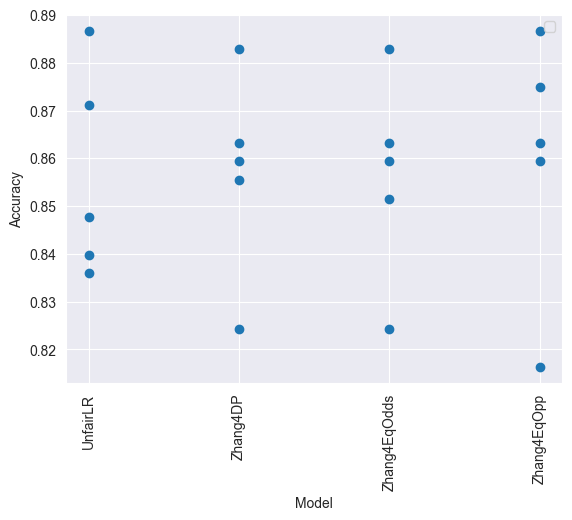

In [50]:
plt.plot()
plt.ylabel('Accuracy')

plt.scatter(model_names, model_accs)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Demographic Disparities

In [51]:
model_dps = unfair['dp'].to_list()+zhang['dp'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_85999/2479496912.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


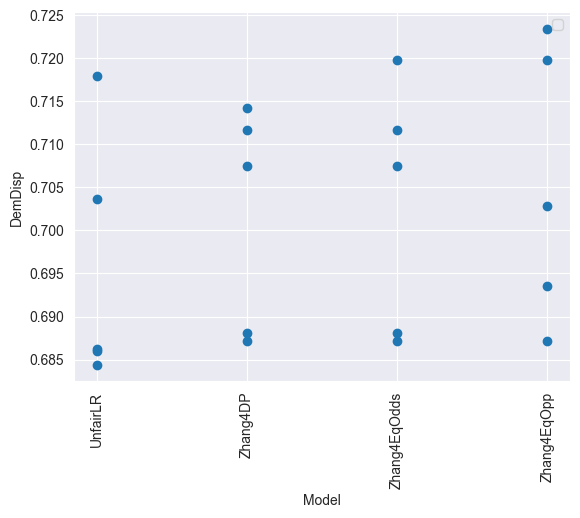

In [52]:
plt.plot()
plt.ylabel('DemDisp')

plt.scatter(model_names, model_dps)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Odds

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_85999/1034882315.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


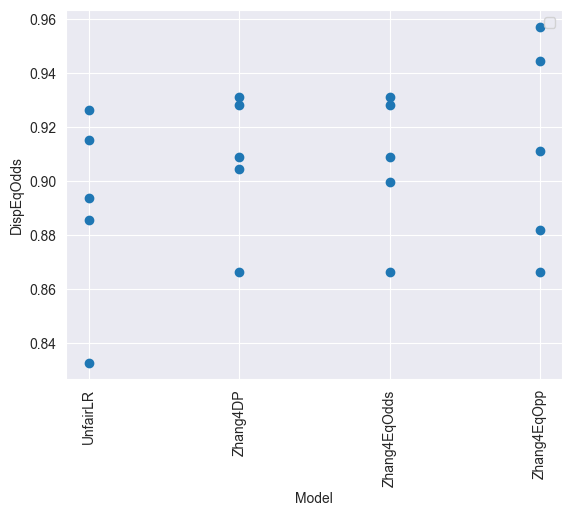

In [53]:
model_deqodds = unfair['deqodds'].to_list()+zhang['deqodds'].to_list()
plt.plot()
plt.ylabel('DispEqOdds')

plt.scatter(model_names, model_deqodds)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Opp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_85999/755552296.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


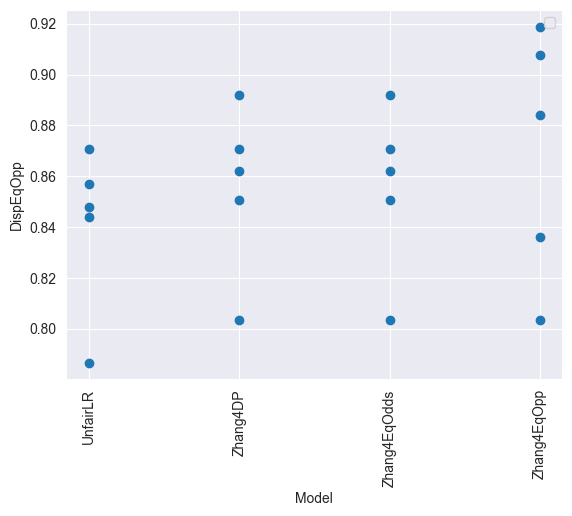

In [54]:
model_deqopps = unfair['deqopp'].to_list()+zhang['deqopp'].to_list()
plt.plot()
plt.ylabel('DispEqOpp')

plt.scatter(model_names, model_deqopps)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Trade-off Acc-DemDisp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_85999/3481502659.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


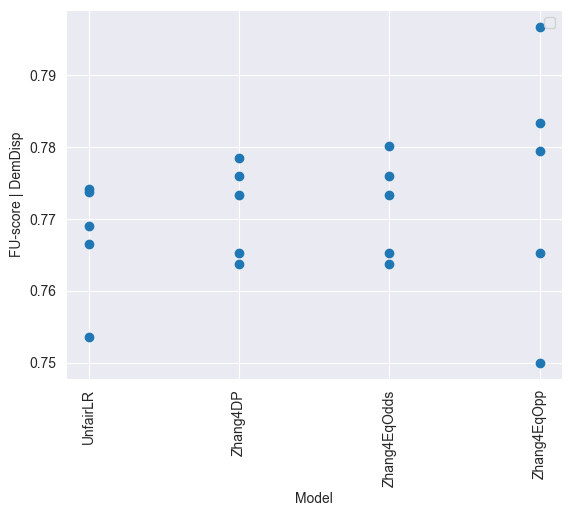

In [55]:
model_trade_dp = unfair['trade_dp'].to_list()+zhang['trade_dp'].to_list()
plt.plot()
plt.ylabel('FU-score | DemDisp')

plt.scatter(model_names, model_trade_dp)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Trade-off Acc-DispEqOdds

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_85999/1478964109.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


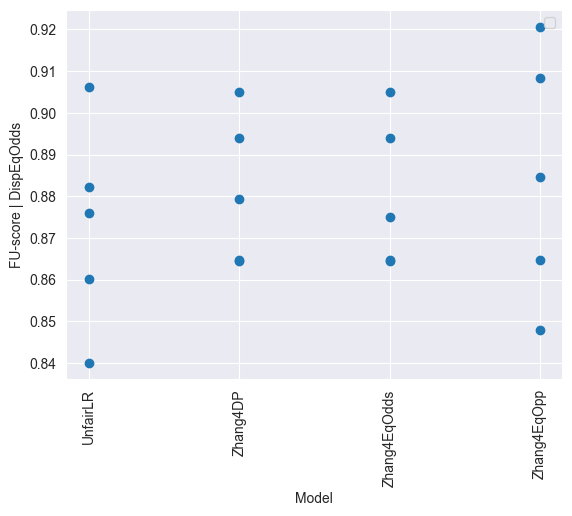

In [56]:
model_trade_deqodds = unfair['trade_deqodds'].to_list()+zhang['trade_deqodds'].to_list()
plt.plot()
plt.ylabel('FU-score | DispEqOdds')

plt.scatter(model_names, model_trade_deqodds)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Trade-off Acc-DispEqOpp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_85999/1705168636.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


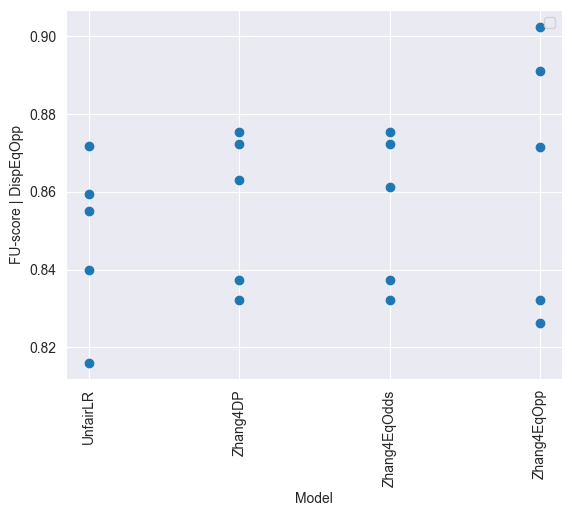

In [57]:
model_trade_deqopp = unfair['trade_deqopp'].to_list()+zhang['trade_deqopp'].to_list()
plt.plot()
plt.ylabel('FU-score | DispEqOpp')

plt.scatter(model_names, model_trade_deqopp)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Acc x DemDisp

In [58]:
'''cmap=sns.light_palette("seagreen")#,as_cmap=True)
cmap'''

'cmap=sns.light_palette("seagreen")#,as_cmap=True)\ncmap'

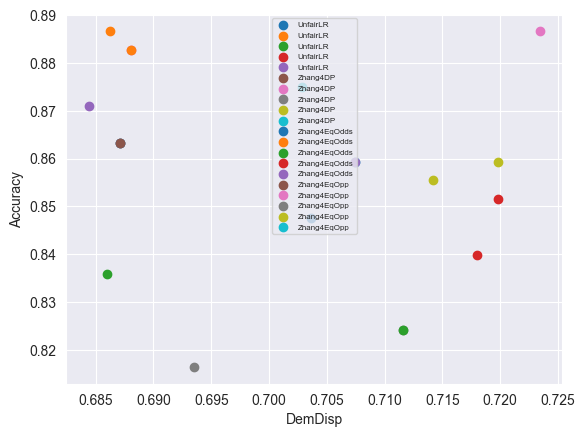

<Figure size 700x700 with 0 Axes>

In [59]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

plt.xlabel('DemDisp')
plt.ylabel('Accuracy')

for i, model_name in enumerate(model_names):
    plt.scatter(model_dps[i], model_accs[i], label=model_name)#, color=cmap[i])
plt.legend(loc='upper center', fontsize='xx-small')
plt.figure(figsize=(7,7))

plt.show()

## Plotting Acc x DispEqOdds

## Plotting Acc x DispEqOpp

# Pro artigo

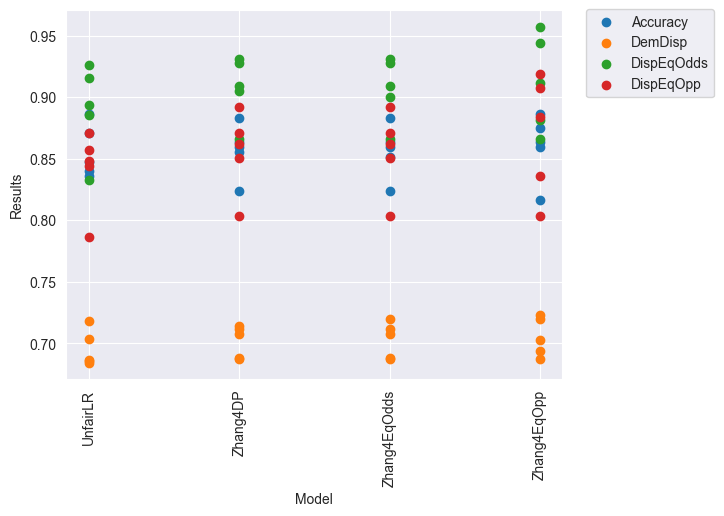

In [60]:

plt.plot()
plt.ylabel('Results')

plt.scatter(model_names, model_accs)
plt.scatter(model_names, model_dps)
plt.scatter(model_names, model_deqodds)
plt.scatter(model_names, model_deqopps)#, label = "ZHANG DemPar")


plt.xlabel('Model')
plt.xticks(rotation=90)
#plt.figure(figsize=(15,12))
#plt.yticks(range(0.755, 0.985))
#plt.yscale('log')
#plt.yticks([0.755, 0.80, 0.805, 0.81, 0.815, 0.82, 0.825, 0.83, 0.835, 0.84, 0.845, 0.85, 0.855, 0.86, 0.865, 0.87, 0.875, 0.88, 0.885, 0.89, 0.895, 0.90, 0.905, 0.91, 0.915, 0.92, 0.925, 0.93, 0.935, 0.94, 0.945, 0.95, 0.955, 0.96, 0.965, 0.97, 0.975,0.98, 0.985])
plt.legend(['Accuracy', 'DemDisp', 'DispEqOdds', 'DispEqOpp'], bbox_to_anchor=(1.32,1.02), loc="upper right")
plt.show()

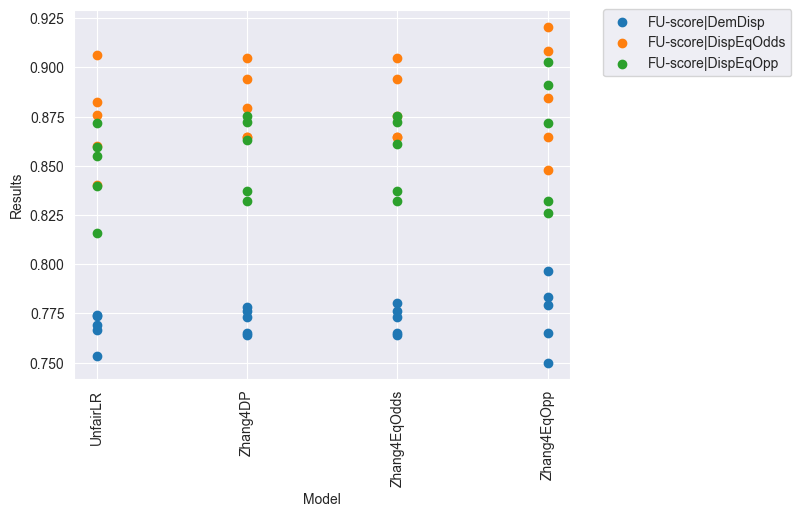

In [61]:

plt.plot()
plt.ylabel('Results')

plt.scatter(model_names, model_trade_dp)
plt.scatter(model_names, model_trade_deqodds)
plt.scatter(model_names, model_trade_deqopp)#, label = "ZHANG DemPar")


plt.xlabel('Model')
plt.xticks(rotation=90)
#plt.figure(figsize=(15,12))
#plt.yticks(range(0.755, 0.985))
#plt.yscale('log')
#plt.yticks([0.755, 0.80, 0.805, 0.81, 0.815, 0.82, 0.825, 0.83, 0.835, 0.84, 0.845, 0.85, 0.855, 0.86, 0.865, 0.87, 0.875, 0.88, 0.885, 0.89, 0.895, 0.90, 0.905, 0.91, 0.915, 0.92, 0.925, 0.93, 0.935, 0.94, 0.945, 0.95, 0.955, 0.96, 0.965, 0.97, 0.975,0.98, 0.985])
plt.legend(['FU-score|DemDisp', 'FU-score|DispEqOdds', 'FU-score|DispEqOpp'], bbox_to_anchor=(1.46,1.02), loc="upper right")
plt.show()